# Early Stopping

# Import Libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from mlxtend.plotting import plot_decision_regions

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [68]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy
from keras.callbacks import EarlyStopping

In [54]:
import time

# Make Dataset

In [55]:
X, y = make_classification(
    n_samples=50,        # number of samples
    n_features=2,         # total number of features
    n_informative=2,       # number of informative features
    n_redundant=0,         # number of redundant features (changed from 2 to 0)
    n_repeated=0,          # no repeated features
    n_classes=2,           # binary classification
    n_clusters_per_class=2,# clusters per class
    weights=[0.5, 0.5],    # balanced classes
    class_sep=1.5,         # separation between classes
    random_state=42        # reproducibility
)
X.shape, y.shape

((50, 2), (50,))

# Train Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale Dataset

In [57]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Build

In [58]:
model1 = Sequential()
model1.add(Input(shape=(2,)))
model1.add(Dense(64, activation=sigmoid))
model1.add(Dense(1, activation=sigmoid))

## Model Compile

In [59]:
model1.compile(
    loss=BinaryCrossentropy(),
    optimizer=SGD(),
    metrics=['accuracy']
)

## Model Trainning

In [60]:
timex = time.time()
history = model1.fit(x=X_train, y=y_train, epochs=3000, validation_data=(X_test, y_test), verbose=0)
print(time.time() - timex)

279.203328371048


## Plot History

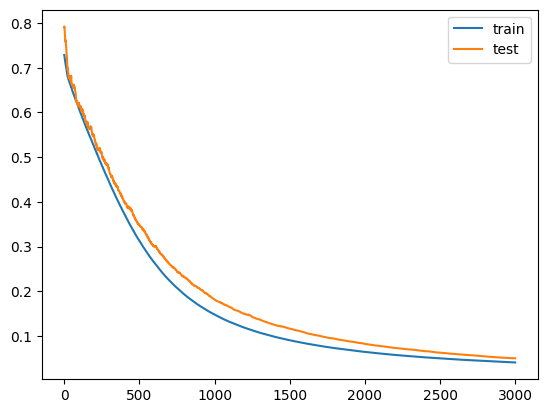

In [61]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


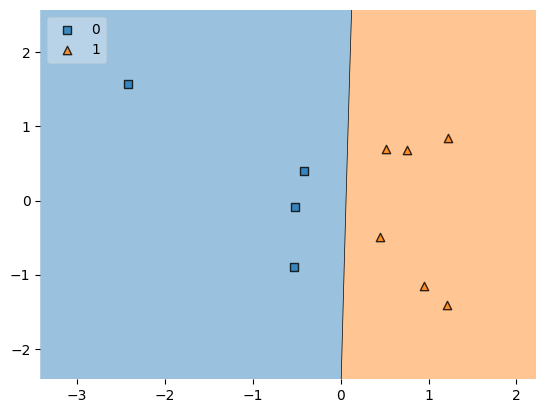

In [65]:
plot_decision_regions(X_test, y_test.ravel(), clf = model1, legend=2)
plt.show()

# Early Stopping

In [66]:
model2 = Sequential()
model2.add(Input(shape=(2,)))
model2.add(Dense(64, activation=sigmoid))
model2.add(Dense(1, activation=sigmoid))

## Model Compile

In [74]:
model2.compile(
    loss=BinaryCrossentropy(),
    optimizer=SGD(),
    metrics=['accuracy']
)

## Callback
```Python
keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=0,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)
```

In [75]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

## Model Trainning

In [76]:
history = model2.fit(
    x=X_train,
    y=y_train,
    epochs=3000,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[callback]
)

Epoch 1/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.3854 - loss: 0.7004 - val_accuracy: 0.5000 - val_loss: 0.7027
Epoch 2/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4896 - loss: 0.6997 - val_accuracy: 0.5000 - val_loss: 0.7022
Epoch 3/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5208 - loss: 0.6969 - val_accuracy: 0.6000 - val_loss: 0.7017
Epoch 4/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4833 - loss: 0.6978 - val_accuracy: 0.4000 - val_loss: 0.7065
Epoch 5/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5167 - loss: 0.6956 - val_accuracy: 0.4000 - val_loss: 0.7075
Epoch 6/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5167 - loss: 0.6956 - val_accuracy: 0.4000 - val_loss: 0.7083
Epoch 7/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5271 - loss: 0.6926 - val_accuracy: 0.4000 - val_loss: 0.7068
Epoch 8/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5687 - loss: 0.6888 - val_accuracy: 0.4000 - 

## Plot History

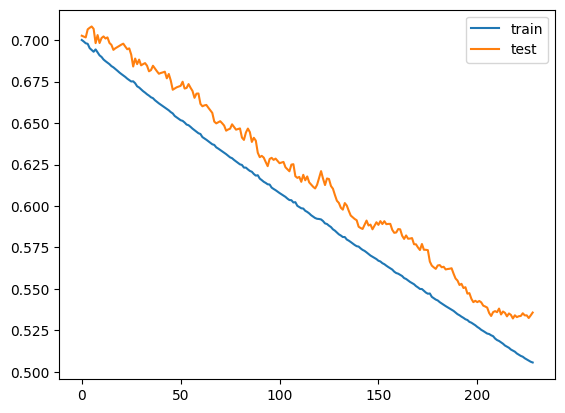

In [77]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


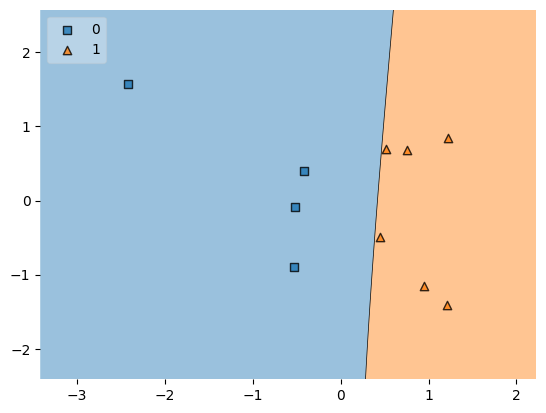

In [78]:
plot_decision_regions(X_test, y_test.ravel(), clf = model2, legend=2)
plt.show()